<a href="https://colab.research.google.com/github/BeanQueso/dsrp/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Use in Important Software Tasks

### Do trust and company safeguards match how professional developers use AI in code review, deployment, monitoring, and predictive analytics?

I originally studied whether starting with AI was connected to longer search time. That question became difficult to defend because the survey only records the first source, not the full search process. This notebook pivots to a clearer question using variables the survey measures directly: AI workflow tasks, trust in AI accuracy, and reported security-policy gaps.

The analysis is observational. It can identify patterns and gaps, but it cannot prove that AI causes unsafe software practices.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
except ImportError:
    %pip install -q xgboost
    from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("survey_results_public.csv")
df.shape

(65437, 114)

In [ ]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## 1. Choose the cohort and variables

I kept professional developers who said they currently use AI and listed at least one task where they use it. Missing trust or challenge responses are left missing until an analysis specifically needs them; they are not automatically treated as “no risk.”

In [ ]:
columns = [
    "ResponseId", "MainBranch", "AISelect", "AIToolCurrently Using",
    "AIAcc", "AIComplex", "AISent", "AIThreat", "AIChallenges",
    "WorkExp", "JobSat", "Age", "DevType", "OrgSize",
    "Industry", "RemoteWork"
]

df[columns].isna().sum().to_frame("Missing values")

,Missing values
ResponseId,0
MainBranch,0
AISelect,4530
AIToolCurrently Using,30365
AIAcc,28135
AIComplex,28416
AISent,19564
AIThreat,20748
AIChallenges,27906
WorkExp,35779


In [ ]:
ai = df[
    (df["MainBranch"] == "I am a developer by profession")
    & (df["AISelect"] == "Yes")
    & df["AIToolCurrently Using"].notna()
].copy()

ai.shape

(27756, 114)

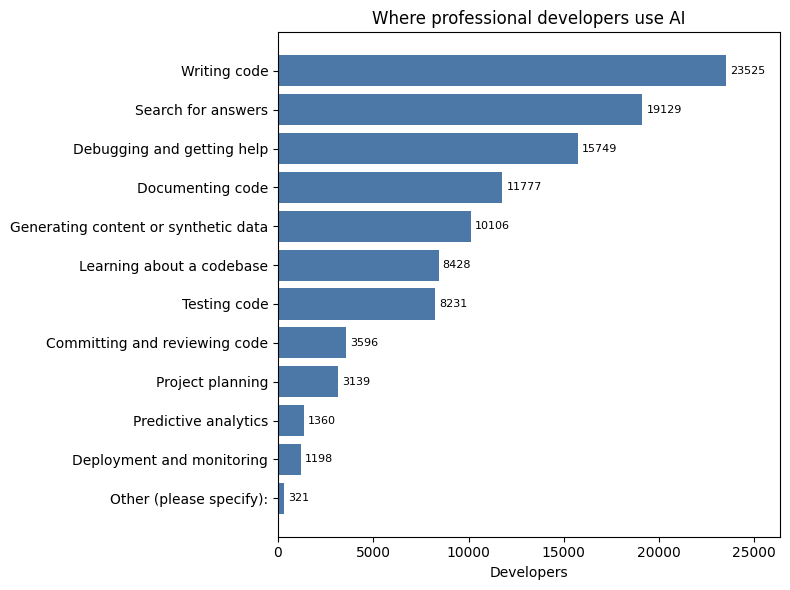

In [ ]:
task_counts = (
    ai["AIToolCurrently Using"]
    .str.split(";")
    .explode()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(8, 6))
bars = plt.barh(task_counts.index, task_counts.values, color="#4C78A8")
plt.bar_label(bars, padding=3, fontsize=8)
plt.title("Where professional developers use AI")
plt.xlabel("Developers")
plt.xlim(0, task_counts.max() * 1.12)
plt.tight_layout()
plt.show()

## 2. Define the important software tasks

The main outcome equals 1 when someone uses AI for **committing or reviewing code, deployment or monitoring, or predictive analytics**. These tasks can directly affect production systems or important decisions. I also created a broader version that includes testing, so I can check whether the conclusion depends on where I draw the boundary.

In [ ]:
important_tasks = {
    "Committing and reviewing code",
    "Deployment and monitoring",
    "Predictive analytics"
}

broad_tasks = important_tasks | {"Testing code"}

task_sets = ai["AIToolCurrently Using"].str.split(";").apply(set)
ai["ImportantTaskUse"] = task_sets.apply(
    lambda tasks: bool(tasks & important_tasks)
).astype(int)
ai["BroadCriticalUse"] = task_sets.apply(
    lambda tasks: bool(tasks & broad_tasks)
).astype(int)

In [ ]:
definition_check = pd.DataFrame({
    "Definition": ["Strict", "Broad, including testing"],
    "Developers": [
        ai["ImportantTaskUse"].sum(),
        ai["BroadCriticalUse"].sum()
    ],
    "Percent": [
        ai["ImportantTaskUse"].mean() * 100,
        ai["BroadCriticalUse"].mean() * 100
    ]
})

definition_check.round(1)

,Definition,Developers,Percent
0,Strict,4807,17.3
1,"Broad, including testing",10719,38.6


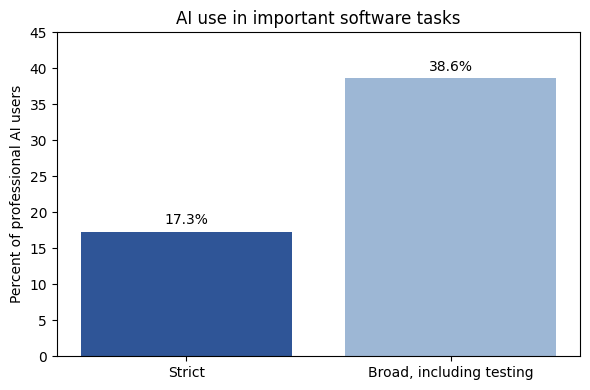

In [ ]:
plt.figure(figsize=(6, 4))
bars = plt.bar(
    definition_check["Definition"],
    definition_check["Percent"],
    color=["#2F5597", "#9DB7D5"]
)
plt.bar_label(bars, fmt="%.1f%%", padding=3)
plt.title("AI use in important software tasks")
plt.ylabel("Percent of professional AI users")
plt.ylim(0, 45)
plt.tight_layout()
plt.show()

## 3. Does trust change how AI is used?

If developers respond to uncertainty, use in these tasks should decrease as trust in AI accuracy decreases. The percentages below use only respondents who answered the trust question.

In [ ]:
trust_order = [
    "Highly distrust",
    "Somewhat distrust",
    "Neither trust nor distrust",
    "Somewhat trust",
    "Highly trust"
]

trust_rates = (
    ai.dropna(subset=["AIAcc"])
    .groupby("AIAcc")["ImportantTaskUse"]
    .agg(["count", "mean"])
    .reindex(trust_order)
)
trust_rates["Percent"] = trust_rates["mean"] * 100

trust_rates[["count", "Percent"]].round(1)

,count,Percent
AIAcc,,
Highly distrust,2249,10.4
Somewhat distrust,6437,11.6
Neither trust nor distrust,7538,17.5
Somewhat trust,10907,21.0
Highly trust,611,34.9


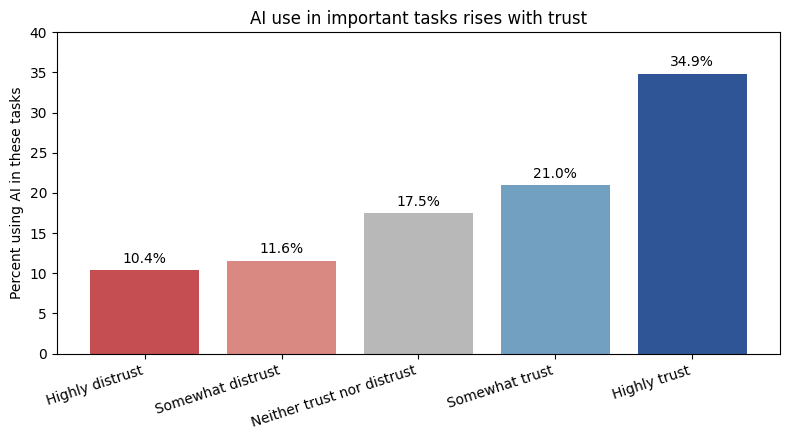

In [ ]:
plt.figure(figsize=(8, 4.5))
bars = plt.bar(
    trust_rates.index,
    trust_rates["Percent"],
    color=["#C44E52", "#D98982", "#B8B8B8", "#72A0C1", "#2F5597"]
)
plt.bar_label(bars, fmt="%.1f%%", padding=3)
plt.title("AI use in important tasks rises with trust")
plt.ylabel("Percent using AI in these tasks")
plt.xticks(rotation=18, ha="right")
plt.ylim(0, 40)
plt.tight_layout()
plt.savefig("trust_vs_important_task_use.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
complex_order = [
    "Very poor at handling complex tasks",
    "Bad at handling complex tasks",
    "Neither good or bad at handling complex tasks",
    "Good, but not great at handling complex tasks",
    "Very well at handling complex tasks"
]

complex_rates = (
    ai.dropna(subset=["AIComplex"])
    .groupby("AIComplex")["ImportantTaskUse"]
    .mean()
    .reindex(complex_order)
    .mul(100)
)

complex_rates.round(1)

AIComplex
Very poor at handling complex tasks              10.9
Bad at handling complex tasks                    12.7
Neither good or bad at handling complex tasks    17.2
Good, but not great at handling complex tasks    22.8
Very well at handling complex tasks              39.9
Name: ImportantTaskUse, dtype: float64

## 4. Compare use with trust and company policies

The survey asks whether companies lack policies to reduce AI security risks, whether AI lacks company context, and whether AI creates more work. These are separate flags, not a combined score. Each flag is calculated only for respondents who answered the challenges question.

In [ ]:
ai["DistrustAI"] = np.where(
    ai["AIAcc"].isna(),
    np.nan,
    ai["AIAcc"].isin(["Somewhat distrust", "Highly distrust"]).astype(int)
)

ai["SecurityPolicyGap"] = ai["AIChallenges"].str.contains(
    "right policies in place to reduce security risks", regex=False
).astype("Int64")

ai["LacksCompanyContext"] = ai["AIChallenges"].str.contains(
    "lack context of codebase", case=False, regex=False
).astype("Int64")

ai["CreatesMoreWork"] = ai["AIChallenges"].str.contains(
    "create more work", case=False, regex=False
).astype("Int64")

In [ ]:
risk_rows = []

for column, label in {
    "DistrustAI": "Distrusts AI accuracy",
    "SecurityPolicyGap": "Reports missing security policies",
    "LacksCompanyContext": "Reports missing company context",
    "CreatesMoreWork": "Reports AI creates more work"
}.items():
    complete = ai.dropna(subset=[column])
    rates = complete.groupby(column)["ImportantTaskUse"].mean() * 100
    risk_rows.append({
        "Issue": label,
        "No issue": rates.loc[0],
        "Issue reported": rates.loc[1],
        "Difference": rates.loc[1] - rates.loc[0]
    })

risk_summary = pd.DataFrame(risk_rows)
risk_summary.round(1)

,Issue,No issue,Issue reported,Difference
0,Distrusts AI accuracy,20.1,11.3,-8.8
1,Reports missing security policies,16.6,17.7,1.0
2,Reports missing company context,18.2,16.3,-1.9
3,Reports AI creates more work,16.5,20.3,3.8


In [ ]:
complete_risk = ai.dropna(subset=["AIAcc", "AIChallenges"]).copy()
complete_risk["TrustOrPolicyConcern"] = (
    complete_risk["DistrustAI"].eq(1)
    | complete_risk["SecurityPolicyGap"].eq(1)
)

important_task_users = complete_risk[complete_risk["ImportantTaskUse"] == 1]

concern_summary = pd.Series({
    "Complete responses": len(complete_risk),
    "Users of AI in important tasks": len(important_task_users),
    "These users with distrust or a security-policy gap": important_task_users["TrustOrPolicyConcern"].sum(),
    "Percent of these users with either concern": important_task_users["TrustOrPolicyConcern"].mean() * 100
})

concern_summary.round(1)

Complete responses                                    24119.0
Users of AI in important tasks                         4094.0
These users with distrust or a security-policy gap     1992.0
Percent of these users with either concern               48.7
dtype: float64

## 5. Test the two central relationships

The chi-square tests ask whether each concern and AI use in the selected tasks are independent. Cramér’s V is included because a large sample can make very small relationships statistically significant.

In [ ]:
def chi_square_result(data, variable):
    complete = data.dropna(subset=[variable])
    table = pd.crosstab(complete[variable], complete["ImportantTaskUse"])
    chi2, p_value, degrees_freedom, _ = chi2_contingency(table)
    cramers_v = np.sqrt(
        chi2 / (table.to_numpy().sum() * min(table.shape[0] - 1, table.shape[1] - 1))
    )
    return table, chi2, p_value, degrees_freedom, cramers_v

In [ ]:
trust_table, trust_chi2, trust_p, trust_dof, trust_v = chi_square_result(
    ai, "DistrustAI"
)

trust_test = pd.Series({
    "Chi-square": trust_chi2,
    "Degrees of freedom": trust_dof,
    "p-value": trust_p,
    "Cramer's V": trust_v
})

trust_table, trust_test

(ImportantTaskUse      0     1
 DistrustAI                   
 0.0               15232  3824
 1.0                7705   981,
 Chi-square            3.200654e+02
 Degrees of freedom    1.000000e+00
 p-value               1.401677e-71
 Cramer's V            1.074114e-01
 dtype: float64)

In [ ]:
policy_table, policy_chi2, policy_p, policy_dof, policy_v = chi_square_result(
    ai, "SecurityPolicyGap"
)

policy_test = pd.Series({
    "Chi-square": policy_chi2,
    "Degrees of freedom": policy_dof,
    "p-value": policy_p,
    "Cramer's V": policy_v
})

policy_table, policy_test

(ImportantTaskUse       0     1
 SecurityPolicyGap             
 0                  13660  2728
 1                   6369  1367,
 Chi-square            3.839997
 Degrees of freedom    1.000000
 p-value               0.050044
 Cramer's V            0.012617
 dtype: float64)

## 6. Adjust for differences between developers and workplaces

The raw percentages could be influenced by who answered the survey. I use logistic regression to estimate each relationship while accounting for experience, role, industry, company size, age, remote work, perceived AI complexity, and other reported AI problems. An adjusted odds ratio of 1 means no remaining relationship; values below 1 mean lower odds and values above 1 mean higher odds.

In [ ]:
adjusted_data = ai.dropna(
    subset=["AIAcc", "AIComplex", "AIChallenges"]
).copy()

adjusted_data["WorkExp5"] = adjusted_data["WorkExp"].fillna(
    adjusted_data["WorkExp"].median()
) / 5

for column in ["Age", "DevType", "OrgSize", "Industry", "RemoteWork"]:
    adjusted_data[column] = adjusted_data[column].fillna("Missing")

adjusted_formula = '''
ImportantTaskUse ~
C(AIAcc, Treatment(reference='Neither trust nor distrust'))
+ C(AIComplex, Treatment(reference='Neither good or bad at handling complex tasks'))
+ SecurityPolicyGap
+ LacksCompanyContext
+ CreatesMoreWork
+ WorkExp5
+ C(Age)
+ C(DevType)
+ C(OrgSize)
+ C(Industry)
+ C(RemoteWork)
'''

adjusted_model = smf.glm(
    formula=adjusted_formula,
    data=adjusted_data,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

len(adjusted_data)

24047

In [ ]:
adjusted_results = pd.DataFrame({
    "Term": adjusted_model.params.index,
    "Odds ratio": np.exp(adjusted_model.params),
    "CI low": np.exp(adjusted_model.conf_int()[0]),
    "CI high": np.exp(adjusted_model.conf_int()[1]),
    "p-value": adjusted_model.pvalues
})

term_labels = {
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly distrust]": "Highly distrust vs. neutral",
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat distrust]": "Somewhat distrust vs. neutral",
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat trust]": "Somewhat trust vs. neutral",
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly trust]": "Highly trust vs. neutral",
    "SecurityPolicyGap": "Reports missing security policies",
    "CreatesMoreWork": "Reports AI creates more work"
}

main_adjusted_results = adjusted_results[
    adjusted_results["Term"].isin(term_labels)
].copy()
main_adjusted_results["Relationship"] = main_adjusted_results["Term"].map(term_labels)

main_adjusted_results[
    ["Relationship", "Odds ratio", "CI low", "CI high", "p-value"]
].round(3)

,Relationship,Odds ratio,CI low,CI high,p-value
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly distrust]",Highly distrust vs. neutral,0.671,0.566,0.795,0.000
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly trust]",Highly trust vs. neutral,1.576,1.260,1.972,0.000
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat distrust]",Somewhat distrust vs. neutral,0.721,0.647,0.802,0.000
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat trust]",Somewhat trust vs. neutral,1.075,0.987,1.170,0.096
SecurityPolicyGap,Reports missing security policies,1.032,0.958,1.111,0.409
CreatesMoreWork,Reports AI creates more work,1.455,1.313,1.612,0.000


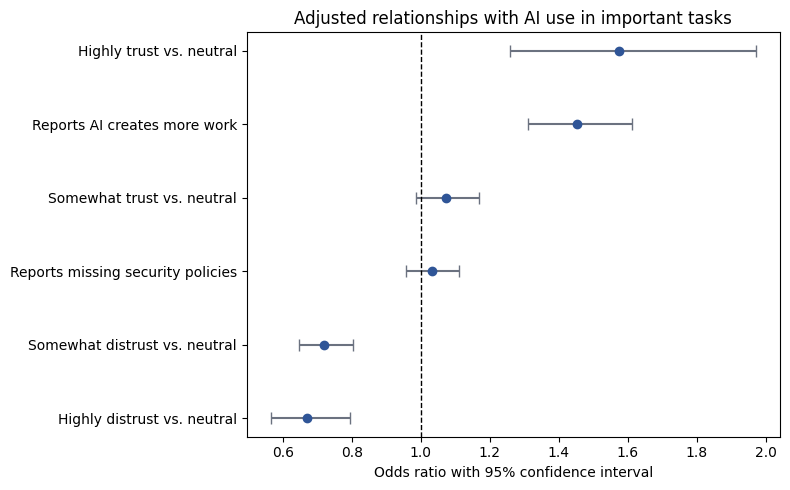

In [ ]:
odds_plot = main_adjusted_results.sort_values("Odds ratio")
x_error = np.vstack([
    odds_plot["Odds ratio"] - odds_plot["CI low"],
    odds_plot["CI high"] - odds_plot["Odds ratio"]
])

plt.figure(figsize=(8, 5))
plt.errorbar(
    odds_plot["Odds ratio"],
    odds_plot["Relationship"],
    xerr=x_error,
    fmt="o",
    color="#2F5597",
    ecolor="#6B7280",
    capsize=4
)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.title("Adjusted relationships with AI use in important tasks")
plt.xlabel("Odds ratio with 95% confidence interval")
plt.tight_layout()
plt.savefig("adjusted_odds_ratios.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Check whether a complicated prediction model adds anything

The main goal is explanation, not identifying individual developers. I compare one interpretable logistic regression with XGBoost to see whether nonlinear complexity adds much. Because only about 17% of the cohort is in the positive class, the models are class-weighted and evaluated with balanced accuracy, recall, specificity, and ROC-AUC rather than accuracy alone.

In [ ]:
model_data = ai.dropna(subset=["AIAcc", "AIChallenges"]).copy()

numeric_features = ["WorkExp", "JobSat"]
categorical_features = [
    "AIAcc", "AIComplex", "AISent", "AIThreat", "Age",
    "DevType", "OrgSize", "Industry", "RemoteWork"
]
binary_features = [
    "SecurityPolicyGap", "LacksCompanyContext", "CreatesMoreWork"
]
feature_columns = numeric_features + categorical_features + binary_features

X = model_data[feature_columns]
y = model_data["ImportantTaskUse"]

X.shape, y.mean()

((24119, 14), np.float64(0.16974169741697417))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]), categorical_features),
    ("binary", SimpleImputer(strategy="most_frequent"), binary_features)
])

In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

positive_weight = y_train.eq(0).sum() / y_train.eq(1).sum()
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=positive_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [ ]:
def evaluate_model(name, model):
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]
    specificity = ((prediction == 0) & (y_test.to_numpy() == 0)).sum() / y_test.eq(0).sum()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Error rate": 1 - accuracy_score(y_test, prediction),
        "Balanced accuracy": balanced_accuracy_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "Specificity": specificity,
        "ROC-AUC": roc_auc_score(y_test, probability)
    }

baseline_prediction = np.zeros(len(y_test), dtype=int)
baseline_row = {
    "Model": "Always predict no",
    "Accuracy": accuracy_score(y_test, baseline_prediction),
    "Error rate": 1 - accuracy_score(y_test, baseline_prediction),
    "Balanced accuracy": balanced_accuracy_score(y_test, baseline_prediction),
    "Recall": 0.0,
    "Specificity": 1.0,
    "ROC-AUC": 0.5
}

model_results = pd.DataFrame([
    baseline_row,
    evaluate_model("Logistic regression", logistic_model),
    evaluate_model("XGBoost", xgb_model)
]).set_index("Model")

model_results.round(3)

,Accuracy,Error rate,Balanced accuracy,Recall,Specificity,ROC-AUC
Model,,,,,,
Always predict no,0.830,0.170,0.500,0.000,1.00,0.500
Logistic regression,0.615,0.385,0.605,0.590,0.62,0.643
XGBoost,0.614,0.386,0.603,0.586,0.62,0.643


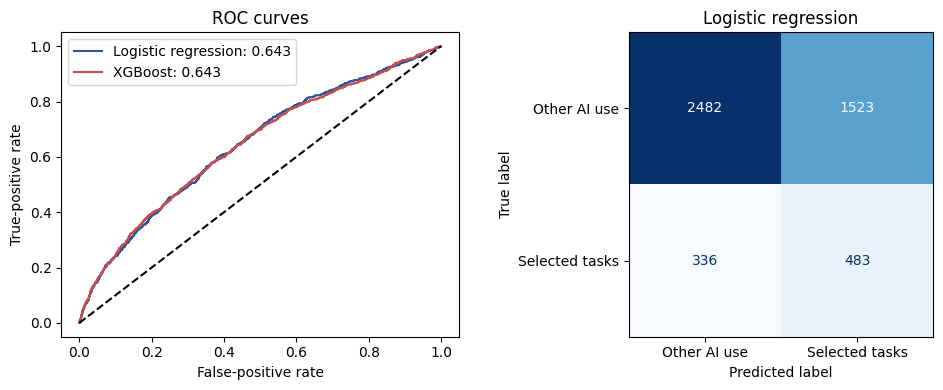

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for name, model, color in [
    ("Logistic regression", logistic_model, "#2F5597"),
    ("XGBoost", xgb_model, "#C44E52")
]:
    probability = model.predict_proba(X_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probability)
    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{name}: {roc_auc_score(y_test, probability):.3f}",
        color=color
    )

axes[0].plot([0, 1], [0, 1], "--", color="black")
axes[0].set_title("ROC curves")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_model.predict(X_test),
    display_labels=["Other AI use", "Selected tasks"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title("Logistic regression")

plt.tight_layout()
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logistic_cv_auc = cross_val_score(
    logistic_model, X, y, cv=cv, scoring="roc_auc", n_jobs=1
)
xgb_cv_auc = cross_val_score(
    xgb_model, X, y, cv=cv, scoring="roc_auc", n_jobs=1
)

cv_results = pd.DataFrame({
    "Model": ["Logistic regression", "XGBoost"],
    "Mean ROC-AUC": [logistic_cv_auc.mean(), xgb_cv_auc.mean()],
    "Standard deviation": [logistic_cv_auc.std(), xgb_cv_auc.std()]
}).set_index("Model")

cv_results.round(3)

,Mean ROC-AUC,Standard deviation
Model,,
Logistic regression,0.637,0.012
XGBoost,0.633,0.012


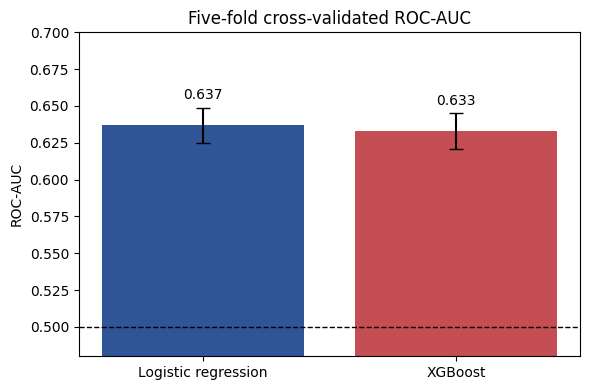

In [ ]:
plt.figure(figsize=(6, 4))
bars = plt.bar(
    cv_results.index,
    cv_results["Mean ROC-AUC"],
    yerr=cv_results["Standard deviation"],
    capsize=5,
    color=["#2F5597", "#C44E52"]
)
plt.bar_label(bars, fmt="%.3f", padding=4)
plt.axhline(0.50, color="black", linestyle="--", linewidth=1)
plt.title("Five-fold cross-validated ROC-AUC")
plt.ylabel("ROC-AUC")
plt.ylim(0.48, 0.70)
plt.tight_layout()
plt.show()

## Conclusion

The strongest result is not that developers blindly trust AI. Use in the selected tasks falls sharply as trust falls, so personal judgment clearly matters. The organizational result is more concerning: after accounting for developer and workplace differences, reporting missing security policies is not connected to meaningfully lower use in code review, deployment, monitoring, or predictive analytics. Among these users with complete responses, almost half either distrust AI accuracy or report that their organization lacks adequate AI security policies.

Adjusted logistic regression is the main model because it answers whether trust and policy relationships remain after accounting for experience, role, industry, company size, and remote work. XGBoost performs no better, so extra complexity does not reveal a hidden high-accuracy pattern. The next meaningful step is a plain-language team AI-use audit that compares actual workflow use with company safeguards.